# 1.0 — Exploración y Preparación de Datos
**Proyecto:** Predicción de Abandono de Vivienda en Sonora  
**Autor:** Francisco  
**Fecha:** 2026-03-26

## Objetivo
Construir un dataset limpio a nivel AGEB para los 6 principales municipios de Sonora, integrando:
- **Censo INEGI 2020** → variables sociodemográficas y de vivienda
- **DENUE 2020** → presencia de negocios como proxy de plusvalía/rezago

La variable objetivo es `TASA_ABANDONO = VIVPAR_DES / VIVTOT`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Estilo profesional consistente para todas las gráficas
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

SEED = 42
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 1. Limpieza del Censo INEGI 2020

### Lógica
El archivo del Censo contiene **tres niveles de granularidad** en el mismo archivo:
- Filas de **entidad/municipio** (totales agregados): `AGEB == '0000'` o `LOC == '0000'`
- Filas de **AGEB** (nivel que nos interesa): `MZA == '000'` con `AGEB != '0000'`
- Filas de **manzana** (demasiado granular): `MZA != '000'`

Es imprescindible filtrar `MZA == '000'` para quedarnos únicamente con las filas de resumen a nivel AGEB. Sin este filtro, cada manzana aparece como un renglón independiente, multiplicando las filas ~10x y duplicando CVE_AGEB.

La clave única `CVE_AGEB` se construye concatenando:
```
ENTIDAD(2) + MUN(3) + LOC(4) + AGEB(4) = 13 caracteres
```
Es **crítico** mantenerla como string; si se convierte a número se pierden los ceros a la izquierda e imposibilita joins con shapefiles o mapas coropléticos.

> **Regla INEGI:** Los asteriscos `*` y `N/D` indican datos suprimidos por confidencialidad estadística. `pd.to_numeric(..., errors='coerce')` los convierte a `NaN` de forma segura sin romper el pipeline.

In [2]:
# Cargamos todo como str para no perder ceros en claves geográficas
censo_raw = pd.read_csv(
    '../data/raw/censo__inegi_2020.csv',
    encoding='utf-8-sig',
    dtype=str
)
print(f'Shape original: {censo_raw.shape}')
print(f'Columnas totales: {len(censo_raw.columns)}')
censo_raw[['ENTIDAD','MUN','NOM_MUN','LOC','AGEB','VIVTOT','VIVPAR_DES']].head(3)

Shape original: (71015, 230)
Columnas totales: 230


,ENTIDAD,MUN,NOM_MUN,LOC,AGEB,VIVTOT,VIVPAR_DES
0,26,000,Total de la entidad Sonora,0000,0000,1079104,140761
1,26,001,Aconchi,0000,0000,1113,165
2,26,001,Aconchi,0001,0000,753,118


In [3]:
# Claves de los 6 municipios principales de Sonora
MUNICIPIOS = {
    '018': 'Cajeme',
    '029': 'Guaymas',
    '030': 'Hermosillo',
    '042': 'Navojoa',
    '043': 'Nogales',
    '055': 'San Luis Río Colorado',
}

# Filtrar: 6 municipios + solo filas de AGEB (MZA=='000' excluye manzanas y totales)
censo = censo_raw[
    (censo_raw['MUN'].isin(MUNICIPIOS.keys())) &
    (censo_raw['MZA'] == '000') &
    (censo_raw['LOC'] != '0000') &
    (censo_raw['AGEB'] != '0000')
].copy()

censo['NOM_MUN'] = censo['MUN'].map(MUNICIPIOS)

print(f'AGEBs filtrados: {len(censo):,}')
print('\nDistribución por municipio:')
print(censo['NOM_MUN'].value_counts().to_string())

AGEBs filtrados: 1,817

Distribución por municipio:
NOM_MUN
Hermosillo               665
Cajeme                   334
San Luis Río Colorado    291
Nogales                  219
Guaymas                  177
Navojoa                  131


In [4]:
# Construir CVE_AGEB de 13 dígitos (siempre como string)
censo['CVE_AGEB'] = (
    censo['ENTIDAD'].str.zfill(2) +
    censo['MUN'].str.zfill(3) +
    censo['LOC'].str.zfill(4) +
    censo['AGEB'].str.zfill(4)
)

# Validación crítica: todos deben tener exactamente 13 caracteres
assert censo['CVE_AGEB'].str.len().eq(13).all(), \
    "ERROR: CVE_AGEB no tiene 13 dígitos en todos los registros"

print(f'CVE_AGEB válida (13 dígitos): ✓')
print(f'Ejemplo: {censo["CVE_AGEB"].iloc[0]}  →  tipo: {type(censo["CVE_AGEB"].iloc[0])}')
censo[['CVE_AGEB','NOM_MUN','VIVTOT','VIVPAR_DES']].head(4)

CVE_AGEB válida (13 dígitos): ✓
Ejemplo: 2601800010531  →  tipo: <class 'str'>


,CVE_AGEB,NOM_MUN,VIVTOT,VIVPAR_DES
10057,2601800010531,Cajeme,1333,199
10096,2601800010546,Cajeme,625,50
10139,2601800010550,Cajeme,794,113
10170,2601800010565,Cajeme,542,51


In [5]:
# Columnas numéricas de interés para el análisis
COLS_NUM = [
    # Vivienda
    'VIVTOT', 'VIVPAR_DES', 'VIVPAR_HAB', 'TVIVPAR', 'OCUPVIVPAR',
    # Hacinamiento y espacio
    'PROM_OCUP', 'VPH_1CUART', 'VPH_2CUART', 'VPH_3YMASC',
    # Carencias materiales (rezago)
    'VPH_PISOTI', 'VPH_NODREN', 'VPH_S_ELEC', 'VPH_SNBIEN',
    'VPH_LETR',  'VPH_SINTIC',
    # Bienes de confort (plusvalía)
    'VPH_AUTOM', 'VPH_INTER', 'VPH_PC',
    # Población
    'POBTOT', 'P_60YMAS',
]

# Conservar solo las que existen en este archivo
COLS_NUM = [c for c in COLS_NUM if c in censo.columns]

# REGLA CRÍTICA: errors='coerce' convierte '*' y 'N/D' en NaN
for col in COLS_NUM:
    censo[col] = pd.to_numeric(censo[col], errors='coerce')

print(f'Columnas convertidas a numérico: {len(COLS_NUM)}')
print(f'\nPorcentaje de NaN por columna (top 10):')
print(
    (censo[COLS_NUM].isna().mean() * 100)
    .sort_values(ascending=False)
    .head(10)
    .map('{:.1f}%'.format)
    .to_string()
)

Columnas convertidas a numérico: 20

Porcentaje de NaN por columna (top 10):
VPH_S_ELEC    27.7%
VPH_SNBIEN    26.6%
VPH_PISOTI    26.1%
VPH_SINTIC    25.5%
VPH_NODREN    22.3%
VPH_1CUART    19.2%
VPH_LETR      18.7%
VPH_2CUART    14.3%
VIVPAR_DES    12.7%
P_60YMAS      11.0%


---
## 2. Ingeniería de Características: Rezago vs. Plusvalía

### Lógica
Las variables del Censo son **conteos absolutos** (ej. `VPH_PISOTI` = número de viviendas con piso de tierra). Para que los AGEBs grandes y pequeños sean comparables, **normalizamos** cada proxy dividiéndolo entre `VIVPAR_HAB` (viviendas particulares habitadas).

| Variable creada | Fórmula | Interpretación |
|---|---|---|
| `TASA_PISO_TIERRA` | VPH_PISOTI / VIVPAR_HAB | % de viviendas con piso de tierra |
| `TASA_SIN_DRENAJE` | VPH_NODREN / VIVPAR_HAB | % sin acceso a drenaje |
| `TASA_SIN_ELEC` | VPH_S_ELEC / VIVPAR_HAB | % sin electricidad |
| `TASA_SIN_BIENES` | VPH_SNBIEN / VIVPAR_HAB | % sin ningún bien |
| `TASA_1_CUARTO` | VPH_1CUART / VIVPAR_HAB | % con un solo cuarto (proxy hacinamiento) |
| `TASA_LETRINA` | VPH_LETR / VIVPAR_HAB | % con letrina en lugar de sanitario |
| `HACINAMIENTO` | PROM_OCUP | Promedio de ocupantes por vivienda |

El `SCORE_REZAGO` es el promedio simple de estos proxies. Como todos están en escala [0,1] (excepto HACINAMIENTO), captura de forma balanceada la multidimensionalidad del rezago sin requerir normalización adicional en esta etapa.

In [6]:
# --- Variable objetivo ---
# Usamos VIVTOT en el denominador para incluir también viviendas en uso no habitacional
censo['TASA_ABANDONO'] = (
    censo['VIVPAR_DES'] / censo['VIVTOT'].replace(0, np.nan)
)

print('Variable objetivo creada: TASA_ABANDONO')
print(census_desc := censo['TASA_ABANDONO'].describe().map('{:.4f}'.format))
print(f'\nAGEBs con datos válidos: {censo["TASA_ABANDONO"].notna().sum():,}')

Variable objetivo creada: TASA_ABANDONO
count    1471.0000
mean        0.1353
std         0.1047
min         0.0000
25%         0.0787
50%         0.1100
75%         0.1598
max         0.9531
Name: TASA_ABANDONO, dtype: str

AGEBs con datos válidos: 1,471


In [7]:
# Base de normalización: viviendas habitadas (evitar división entre 0)
viv_hab = censo['VIVPAR_HAB'].replace(0, np.nan)

# Proxies de rezago normalizados
censo['TASA_PISO_TIERRA'] = censo['VPH_PISOTI'] / viv_hab
censo['TASA_SIN_DRENAJE'] = censo['VPH_NODREN'] / viv_hab
censo['TASA_SIN_ELEC']    = censo['VPH_S_ELEC']  / viv_hab
censo['TASA_SIN_BIENES']  = censo['VPH_SNBIEN']  / viv_hab
censo['TASA_1_CUARTO']    = censo['VPH_1CUART']  / viv_hab
censo['TASA_LETRINA']     = censo['VPH_LETR']    / viv_hab
censo['HACINAMIENTO']     = censo['PROM_OCUP']   # ya es promedio (escala similar)

# SCORE_REZAGO: promedio de todos los proxies
PROXIES_REZAGO = [
    'TASA_PISO_TIERRA', 'TASA_SIN_DRENAJE', 'TASA_SIN_ELEC',
    'TASA_SIN_BIENES',  'TASA_1_CUARTO',    'TASA_LETRINA',
    'HACINAMIENTO',
]
censo['SCORE_REZAGO'] = censo[PROXIES_REZAGO].mean(axis=1)

print('Variables de rezago creadas exitosamente.')
censo[['CVE_AGEB','NOM_MUN','TASA_ABANDONO','SCORE_REZAGO'] + PROXIES_REZAGO].head(4)

Variables de rezago creadas exitosamente.


,CVE_AGEB,NOM_MUN,TASA_ABANDONO,SCORE_REZAGO,TASA_PISO_TIERRA,TASA_SIN_DRENAJE,TASA_SIN_ELEC,TASA_SIN_BIENES,TASA_1_CUARTO,TASA_LETRINA,HACINAMIENTO
10057,2601800010531,Cajeme,0.149287,0.520688,0.008257,0.006422,0.004587,0.006422,0.028440,NaN,3.07
10096,2601800010546,Cajeme,0.080000,0.400783,0.000000,0.000000,0.000000,0.000000,0.005484,0.0,2.80
10139,2601800010550,Cajeme,0.142317,0.470774,NaN,0.000000,0.000000,0.000000,0.004644,0.0,2.82
10170,2601800010565,Cajeme,0.094096,0.396460,0.008696,0.000000,0.000000,0.000000,0.006522,0.0,2.76


---
## 3. Integración del DENUE 2020

### Lógica
El DENUE (Directorio Estadístico Nacional de Unidades Económicas) registra cada negocio formalmente inscrito. Lo usamos como **proxy de actividad económica** a nivel AGEB:

- **Plusvalía** → negocios que indican inversión y demanda de servicios de alto costo:
  - `522110` Banca múltiple (Bancos)  
  - `722515` Cafeterías, fuentes de sodas, neverías  
  - `531210` Inmobiliarias y corredores de bienes raíces  

- **Rezago** → negocios que revelan economía informal o deprimida:
  - `522452` Casas de empeño  
  - `522451` Montepíos  
  - `466410` Comercio al por menor de artículos usados  

> **Nota:** Los códigos SCIAN del CLAUDE.md (468211, 468212, 522292) corresponden a la clasificación teórica; los códigos efectivos en el DENUE Sonora 2020 son los que aparecen arriba. Los yonques (deshuesaderos) no tienen registro formal como unidad económica en este dataset.

Para el merge usamos la misma llave `CVE_AGEB` de 13 dígitos, construida a partir de los campos `Clave entidad`, `Clave municipio`, `Clave localidad` y `Área geoestadística básica`.

> Los AGEBs del Censo sin coincidencia en el DENUE simplemente no tienen negocios de interés → se rellenan con `0`.

In [8]:
denue_raw = pd.read_csv(
    '../data/raw/denue_sonora_2020.csv',
    encoding='latin1',
    dtype={'Área geoestadística básica ': str}  # preservar como string
)

# Limpiar nombres de columnas (hay una con espacio al final)
denue_raw.columns = denue_raw.columns.str.strip()

# Renombrar columnas clave para comodidad
denue = denue_raw.rename(columns={
    'Código de la clase de actividad SCIAN': 'codigo_act',
    'Área geoestadística básica':            'ageb',
    'Clave entidad':                         'cve_ent',
    'Clave municipio':                       'cve_mun',
    'Clave localidad':                       'cve_loc',
})

# Filtrar solo los 6 municipios de interés (enteros)
MUNICIPIOS_INT = [18, 29, 30, 42, 43, 55]
denue = denue[denue['cve_mun'].isin(MUNICIPIOS_INT)].copy()

print(f'Negocios en los 6 municipios: {len(denue):,}')

Negocios en los 6 municipios: 13,444


In [9]:
# Definir códigos SCIAN con los valores reales del DENUE Sonora 2020
# (verificados contra el catálogo de clases de actividad del archivo)
SCIAN_PLUSVALIA = [522110, 722515, 531210]
SCIAN_REZAGO    = [522452, 522451, 466410]

ETIQUETA = {
    522110: 'Bancos',
    722515: 'Cafeterias',
    531210: 'Inmobiliarias',
    522452: 'Empenhos',
    522451: 'Montepio',
    466410: 'Art_Usados',
}
TIPO = {
    522110: 'Plusvalia', 722515: 'Plusvalia', 531210: 'Plusvalia',
    522452: 'Rezago',    522451: 'Rezago',    466410: 'Rezago',
}

# Filtrar por códigos SCIAN
denue_f = denue[denue['codigo_act'].isin(ETIQUETA.keys())].copy()
denue_f['categoria'] = denue_f['codigo_act'].map(ETIQUETA)
denue_f['tipo']      = denue_f['codigo_act'].map(TIPO)

print(f'Negocios de interés encontrados: {len(denue_f):,}\n')
print(denue_f.groupby(['tipo','categoria']).size()
      .reset_index(name='conteo')
      .to_string(index=False))

Negocios de interés encontrados: 4,821

     tipo     categoria  conteo
Plusvalia        Bancos    1433
Plusvalia    Cafeterias    1552
Plusvalia Inmobiliarias     213
   Rezago    Art_Usados    1374
   Rezago      Empenhos     242
   Rezago      Montepio       7


In [10]:
# Construir CVE_AGEB en el DENUE con el mismo formato de 13 dígitos
denue_f['CVE_AGEB'] = (
    denue_f['cve_ent'].astype(str).str.zfill(2) +
    denue_f['cve_mun'].astype(str).str.zfill(3) +
    denue_f['cve_loc'].astype(str).str.zfill(4) +
    denue_f['ageb'].astype(str).str.strip().str.zfill(4)
)

print(f'Ejemplo CVE_AGEB DENUE: {denue_f["CVE_AGEB"].iloc[0]}')

# --- Pivot 1: Total por tipo (Plusvalia / Rezago) ---
pivot_tipo = (
    denue_f.groupby(['CVE_AGEB', 'tipo'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
# Asegurar que ambas columnas existen aunque no haya registros de algún tipo
for col in ['Plusvalia', 'Rezago']:
    if col not in pivot_tipo.columns:
        pivot_tipo[col] = 0
pivot_tipo = pivot_tipo.rename(columns={'Plusvalia': 'N_PLUSVALIA', 'Rezago': 'N_REZAGO'})

# --- Pivot 2: Conteo por categoría específica ---
pivot_cat = (
    denue_f.groupby(['CVE_AGEB', 'categoria'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
pivot_cat.columns = (
    ['CVE_AGEB'] +
    [f'NEG_{c}' for c in pivot_cat.columns[1:]]
)

print('\nNegocios por AGEB (muestra):')
pivot_tipo.merge(pivot_cat, on='CVE_AGEB').head(4)

Ejemplo CVE_AGEB DENUE: 2601800011281

Negocios por AGEB (muestra):


,CVE_AGEB,N_PLUSVALIA,N_REZAGO,NEG_Art_Usados,NEG_Bancos,NEG_Cafeterias,NEG_Empenhos,NEG_Inmobiliarias,NEG_Montepio
0,2601800010546,5,1,1,1,4,0,0,0
1,2601800010550,17,0,0,0,15,0,2,0
2,2601800010565,10,0,0,0,10,0,0,0
3,260180001057A,20,0,0,3,9,0,8,0


In [11]:
# Merge: Censo + pivot_tipo + pivot_cat
df = (
    censo
    .merge(pivot_tipo, on='CVE_AGEB', how='left')
    .merge(pivot_cat,  on='CVE_AGEB', how='left')
)

# Rellenar NaN en columnas de negocios con 0 (sin negocios en ese AGEB)
neg_cols = [c for c in df.columns if c.startswith('N_') or c.startswith('NEG_')]
df[neg_cols] = df[neg_cols].fillna(0).astype(int)

print(f'Shape del dataset final: {df.shape}')
print(f'AGEBs con al menos 1 negocio de plusvalía: {(df["N_PLUSVALIA"] > 0).sum():,}')
print(f'AGEBs con al menos 1 negocio de rezago:    {(df["N_REZAGO"]    > 0).sum():,}')

df[['CVE_AGEB','NOM_MUN','TASA_ABANDONO','SCORE_REZAGO',
    'N_PLUSVALIA','N_REZAGO'] + neg_cols[2:]].head(4)

Shape del dataset final: (1817, 248)
AGEBs con al menos 1 negocio de plusvalía: 711
AGEBs con al menos 1 negocio de rezago:    509


,CVE_AGEB,NOM_MUN,TASA_ABANDONO,SCORE_REZAGO,N_PLUSVALIA,N_REZAGO,NEG_Art_Usados,NEG_Bancos,NEG_Cafeterias,NEG_Empenhos,NEG_Inmobiliarias,NEG_Montepio
0,2601800010531,Cajeme,0.149287,0.520688,0,0,0,0,0,0,0,0
1,2601800010546,Cajeme,0.080000,0.400783,5,1,1,1,4,0,0,0
2,2601800010550,Cajeme,0.142317,0.470774,17,0,0,0,15,0,2,0
3,2601800010565,Cajeme,0.094096,0.396460,10,0,0,0,10,0,0,0


---
## 4. Análisis Exploratorio (EDA)

### Lógica
Exploramos los datos desde cuatro ángulos:
1. **Distribución de la variable objetivo** por municipio: ¿Qué ciudad tiene más abandono?
2. **Mapa de calor de correlaciones**: ¿Qué variables se asocian más con `TASA_ABANDONO`?
3. **Contraste plusvalía vs. rezago**: ¿Los AGEBs con negocios de plusvalía tienen menos abandono?
4. **Scatter rezago vs. abandono**: ¿El `SCORE_REZAGO` predice el abandono?

In [12]:
# Resumen estadístico del dataset final
VARS_ANALISIS = (
    ['TASA_ABANDONO', 'SCORE_REZAGO'] +
    PROXIES_REZAGO +
    ['N_PLUSVALIA', 'N_REZAGO']
)
df[VARS_ANALISIS].describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
TASA_ABANDONO,1471.0,0.1353,0.1047,0.0,0.0787,0.1100,0.1598,0.9531
SCORE_REZAGO,1724.0,0.6156,0.4064,0.0,0.4840,0.5716,0.7072,8.0000
TASA_PISO_TIERRA,1190.0,0.0503,0.1253,0.0,0.0000,0.0068,0.0284,0.8889
TASA_SIN_DRENAJE,1258.0,0.0405,0.1410,0.0,0.0000,0.0000,0.0095,1.0000
TASA_SIN_ELEC,1156.0,0.0171,0.0834,0.0,0.0000,0.0000,0.0067,1.0000
TASA_SIN_BIENES,1176.0,0.0093,0.0375,0.0,0.0000,0.0000,0.0065,0.6667
TASA_1_CUARTO,1319.0,0.0651,0.1179,0.0,0.0000,0.0193,0.0676,0.7500
TASA_LETRINA,1324.0,0.0492,0.1523,0.0,0.0000,0.0000,0.0094,1.0000
HACINAMIENTO,1724.0,3.0350,1.0169,0.0,2.9900,3.2800,3.5100,8.0000
N_PLUSVALIA,1817.0,1.7210,4.2253,0.0,0.0000,0.0000,2.0000,50.0000


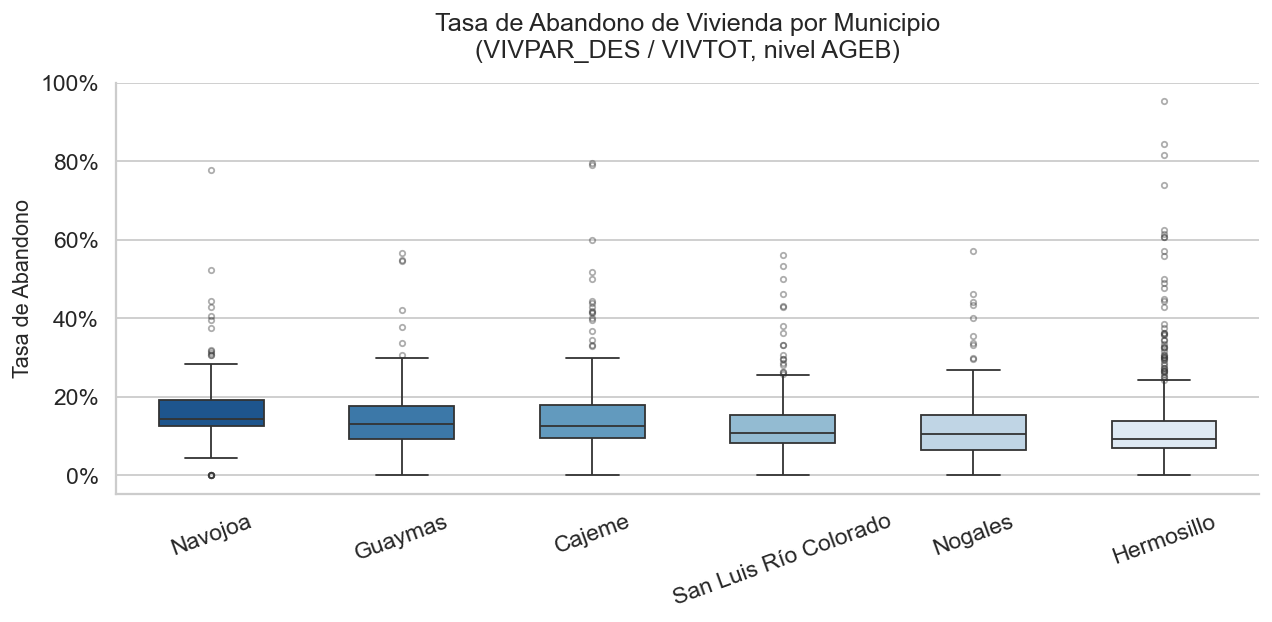

In [13]:
# ── Gráfica 1: Distribución de TASA_ABANDONO por municipio ──────────────────
ORDEN_MUN = (
    df.groupby('NOM_MUN')['TASA_ABANDONO'].median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=df.dropna(subset=['TASA_ABANDONO']),
    x='NOM_MUN', y='TASA_ABANDONO',
    order=ORDEN_MUN,
    palette='Blues_r',
    width=0.55,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=ax
)

ax.set_title('Tasa de Abandono de Vivienda por Municipio\n(VIVPAR_DES / VIVTOT, nivel AGEB)', 
             fontsize=14, pad=14)
ax.set_xlabel('')
ax.set_ylabel('Tasa de Abandono', fontsize=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

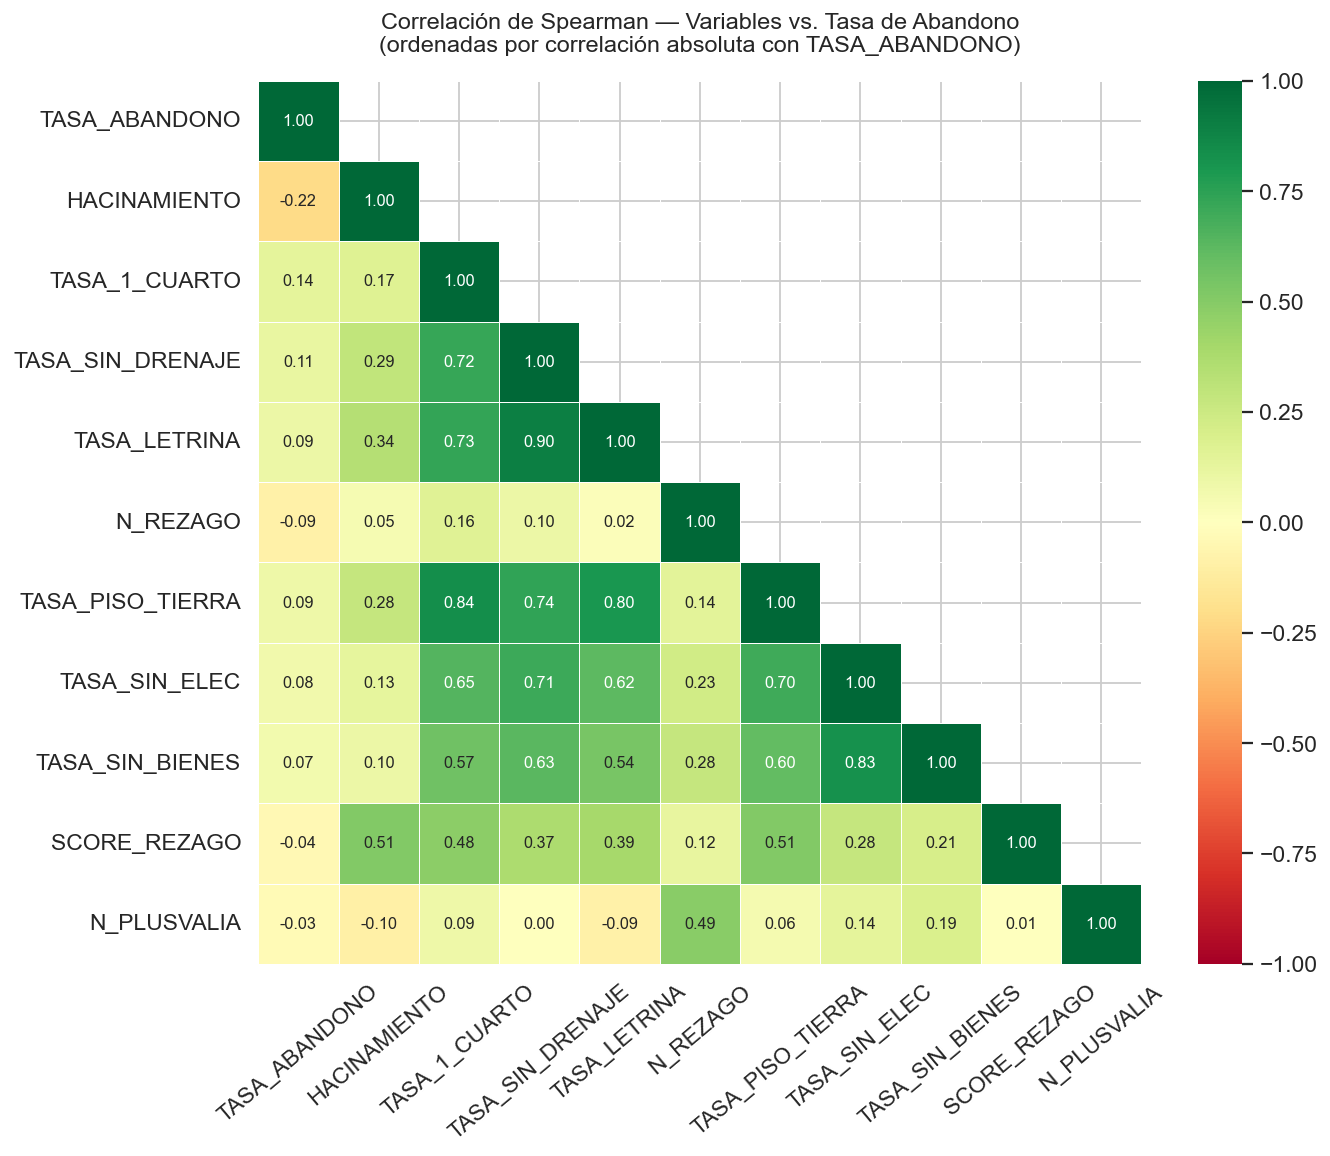

In [14]:
# ── Gráfica 2: Mapa de calor de correlaciones con TASA_ABANDONO ─────────────
VARS_HEATMAP = [
    'TASA_ABANDONO',
    'SCORE_REZAGO',
    'TASA_PISO_TIERRA',
    'TASA_SIN_DRENAJE',
    'TASA_SIN_ELEC',
    'TASA_SIN_BIENES',
    'TASA_1_CUARTO',
    'TASA_LETRINA',
    'HACINAMIENTO',
    'N_PLUSVALIA',
    'N_REZAGO',
]
# Solo las que existen en df
VARS_HEATMAP = [v for v in VARS_HEATMAP if v in df.columns]

corr_matrix = df[VARS_HEATMAP].corr(method='spearman')

# Ordenar por correlación con TASA_ABANDONO
orden_corr = (
    corr_matrix['TASA_ABANDONO']
    .drop('TASA_ABANDONO')
    .abs()
    .sort_values(ascending=False)
    .index.tolist()
)
orden_final = ['TASA_ABANDONO'] + orden_corr
corr_ordenada = corr_matrix.loc[orden_final, orden_final]

# Máscara triángulo superior
mask = np.triu(np.ones_like(corr_ordenada, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_ordenada,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    square=True, ax=ax
)
ax.set_title(
    'Correlación de Spearman — Variables vs. Tasa de Abandono\n'
    '(ordenadas por correlación absoluta con TASA_ABANDONO)',
    fontsize=13, pad=16
)
ax.tick_params(axis='x', rotation=40)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

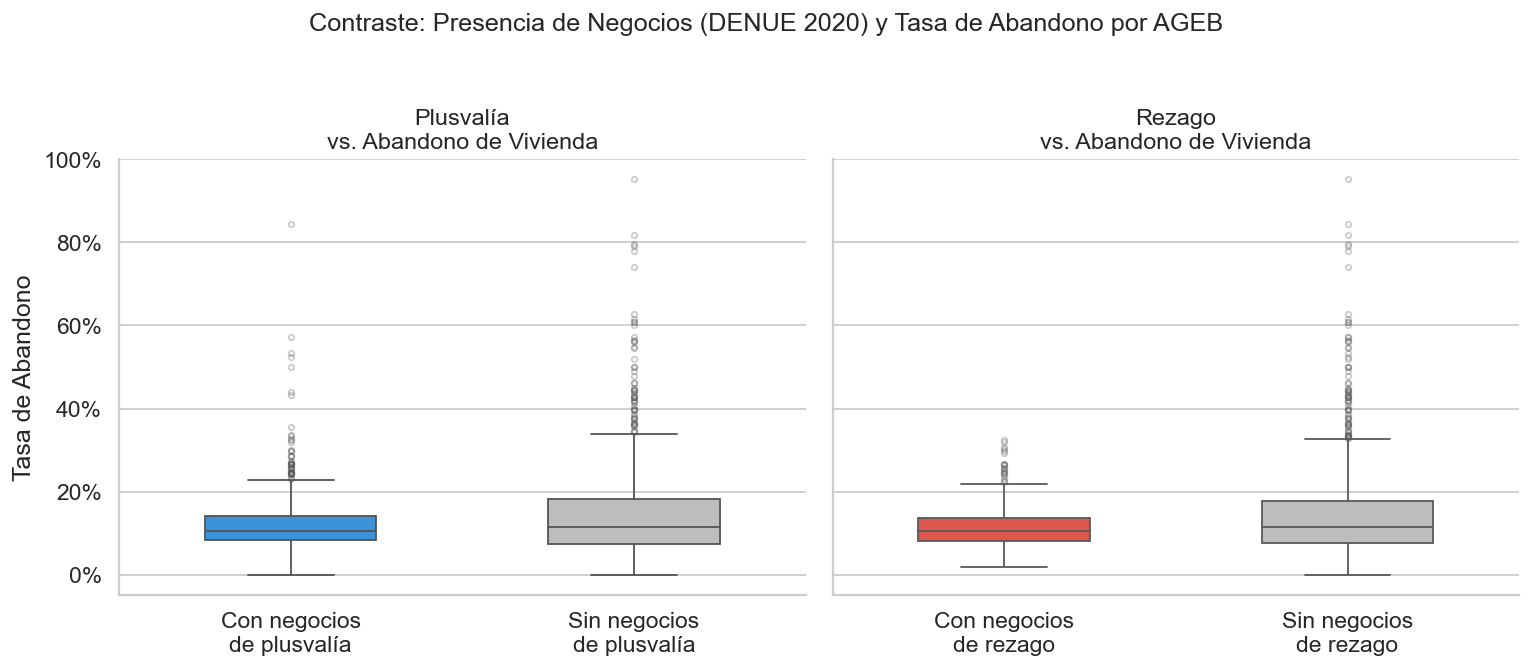

In [15]:
# ── Gráfica 3: Boxplot — Presencia de negocios de Plusvalía vs. Abandono ────
# Creamos variables binarias para clasificar cada AGEB
df['Tiene_Plusvalia'] = df['N_PLUSVALIA'].gt(0).map({True: 'Con negocios\nde plusvalía', False: 'Sin negocios\nde plusvalía'})
df['Tiene_Rezago']    = df['N_REZAGO'].gt(0).map({True: 'Con negocios\nde rezago', False: 'Sin negocios\nde rezago'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Panel A: Plusvalía
sns.boxplot(
    data=df.dropna(subset=['TASA_ABANDONO']),
    x='Tiene_Plusvalia', y='TASA_ABANDONO',
    order=['Con negocios\nde plusvalía', 'Sin negocios\nde plusvalía'],
    palette=['#2196F3', '#BDBDBD'],
    width=0.5,
    flierprops=dict(marker='o', markersize=3, alpha=0.3),
    ax=axes[0]
)
axes[0].set_title('Plusvalía\nvs. Abandono de Vivienda', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Tasa de Abandono')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

# Panel B: Rezago
sns.boxplot(
    data=df.dropna(subset=['TASA_ABANDONO']),
    x='Tiene_Rezago', y='TASA_ABANDONO',
    order=['Con negocios\nde rezago', 'Sin negocios\nde rezago'],
    palette=['#F44336', '#BDBDBD'],
    width=0.5,
    flierprops=dict(marker='o', markersize=3, alpha=0.3),
    ax=axes[1]
)
axes[1].set_title('Rezago\nvs. Abandono de Vivienda', fontsize=13)
axes[1].set_xlabel('')
axes[1].set_ylabel('')

fig.suptitle(
    'Contraste: Presencia de Negocios (DENUE 2020) y Tasa de Abandono por AGEB',
    fontsize=14, y=1.03
)
plt.tight_layout()
plt.show()

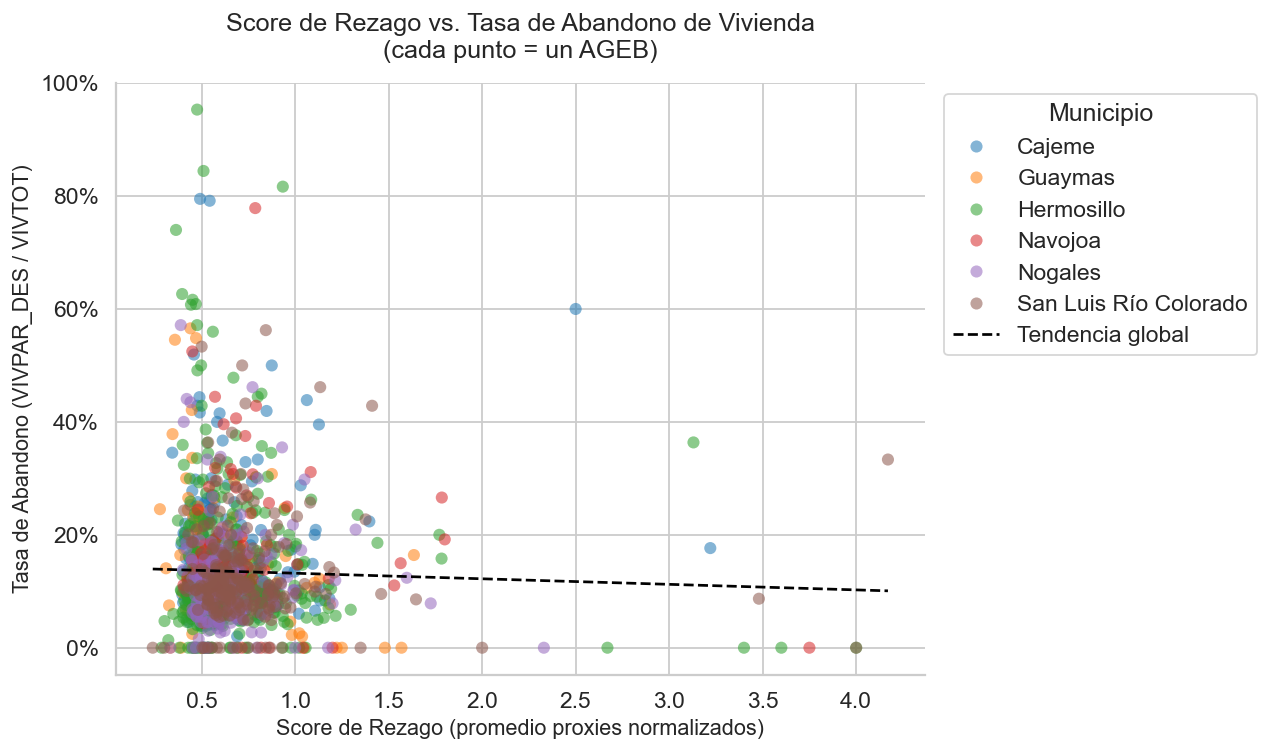

In [16]:
# ── Gráfica 4: Scatter — SCORE_REZAGO vs. TASA_ABANDONO por municipio ───────
df_plot = df.dropna(subset=['TASA_ABANDONO', 'SCORE_REZAGO']).copy()

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df_plot,
    x='SCORE_REZAGO', y='TASA_ABANDONO',
    hue='NOM_MUN',
    palette='tab10',
    alpha=0.55, s=45, edgecolor='none',
    ax=ax
)

# Línea de tendencia global
m, b = np.polyfit(
    df_plot['SCORE_REZAGO'].fillna(0),
    df_plot['TASA_ABANDONO'].fillna(0),
    deg=1
)
x_range = np.linspace(df_plot['SCORE_REZAGO'].min(), df_plot['SCORE_REZAGO'].max(), 100)
ax.plot(x_range, m * x_range + b, color='black', linewidth=1.5,
        linestyle='--', label='Tendencia global', zorder=5)

ax.set_title('Score de Rezago vs. Tasa de Abandono de Vivienda\n(cada punto = un AGEB)', 
             fontsize=14, pad=14)
ax.set_xlabel('Score de Rezago (promedio proxies normalizados)', fontsize=12)
ax.set_ylabel('Tasa de Abandono (VIVPAR_DES / VIVTOT)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(title='Municipio', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

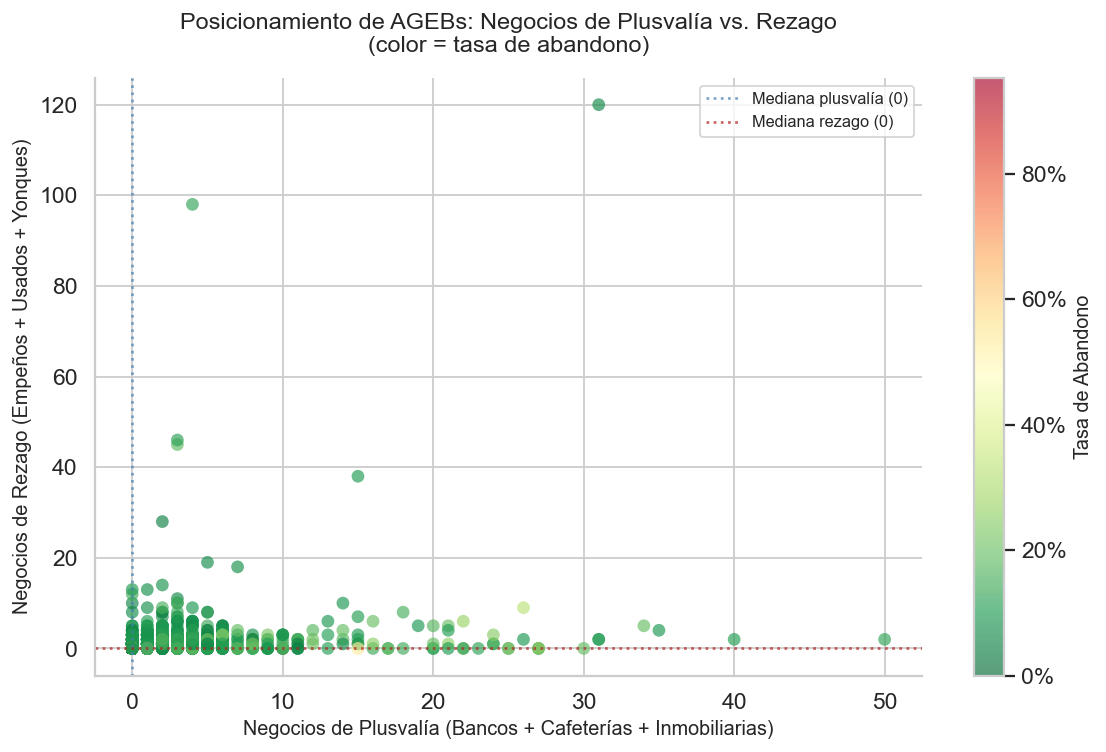

In [17]:
# ── Gráfica 5: Scatter — N_PLUSVALIA vs N_REZAGO coloreado por TASA_ABANDONO
df_plot2 = df.dropna(subset=['TASA_ABANDONO']).copy()

fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    df_plot2['N_PLUSVALIA'],
    df_plot2['N_REZAGO'],
    c=df_plot2['TASA_ABANDONO'],
    cmap='RdYlGn_r',
    alpha=0.65, s=50, edgecolors='none'
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Tasa de Abandono', fontsize=11)
cbar.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

ax.set_title(
    'Posicionamiento de AGEBs: Negocios de Plusvalía vs. Rezago\n'
    '(color = tasa de abandono)',
    fontsize=13, pad=14
)
ax.set_xlabel('Negocios de Plusvalía (Bancos + Cafeterías + Inmobiliarias)', fontsize=11)
ax.set_ylabel('Negocios de Rezago (Empeños + Usados + Yonques)', fontsize=11)

# Cuadrantes conceptuales
mediana_plus = df_plot2['N_PLUSVALIA'].median()
mediana_rez  = df_plot2['N_REZAGO'].median()
ax.axvline(mediana_plus, color='steelblue', linestyle=':', alpha=0.7, label=f'Mediana plusvalía ({mediana_plus:.0f})')
ax.axhline(mediana_rez,  color='firebrick', linestyle=':', alpha=0.7, label=f'Mediana rezago ({mediana_rez:.0f})')

ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [18]:
# ── Resumen final: Top 10 AGEBs con mayor tasa de abandono ──────────────────
cols_resumen = [
    'CVE_AGEB', 'NOM_MUN', 'VIVTOT', 'VIVPAR_DES',
    'TASA_ABANDONO', 'SCORE_REZAGO', 'N_PLUSVALIA', 'N_REZAGO'
]
top10 = (
    df[cols_resumen]
    .dropna(subset=['TASA_ABANDONO'])
    .sort_values('TASA_ABANDONO', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10['TASA_ABANDONO'] = top10['TASA_ABANDONO'].map('{:.1%}'.format)
top10['SCORE_REZAGO']  = top10['SCORE_REZAGO'].map('{:.3f}'.format)
print('Top 10 AGEBs con mayor tasa de abandono:')
top10

Top 10 AGEBs con mayor tasa de abandono:


,CVE_AGEB,NOM_MUN,VIVTOT,VIVPAR_DES,TASA_ABANDONO,SCORE_REZAGO,N_PLUSVALIA,N_REZAGO
0,2603000018620,Hermosillo,64,61.0,95.3%,0.476,0,0
1,2603000017961,Hermosillo,90,76.0,84.4%,0.510,1,0
2,2603000010682,Hermosillo,60,49.0,81.7%,0.934,0,0
3,2601800014233,Cajeme,200,159.0,79.5%,0.492,0,0
4,2601800014515,Cajeme,48,38.0,79.2%,0.543,0,0
5,260420001211A,Navojoa,122,95.0,77.9%,0.787,0,0
6,2603000011479,Hermosillo,100,74.0,74.0%,0.363,0,0
7,2603000018315,Hermosillo,83,52.0,62.7%,0.396,0,0
8,2603000010199,Hermosillo,86,53.0,61.6%,0.451,0,0
9,2603000018264,Hermosillo,115,70.0,60.9%,0.469,0,0


In [19]:
# ── Guardar dataset procesado para siguientes notebooks ─────────────────────
import os
os.makedirs('../data/processed', exist_ok=True)

df.to_csv('../data/processed/ageb_features.csv', index=False, encoding='utf-8-sig')

print(f'Dataset guardado en: data/processed/ageb_features.csv')
print(f'Shape: {df.shape}')
print(f'\nColumnas disponibles para clustering:')
print([c for c in df.columns if c.startswith(('TASA_','SCORE_','N_','NEG_','HACINAMIENTO'))])

Dataset guardado en: data/processed/ageb_features.csv
Shape: (1817, 250)

Columnas disponibles para clustering:
['TASA_ABANDONO', 'TASA_PISO_TIERRA', 'TASA_SIN_DRENAJE', 'TASA_SIN_ELEC', 'TASA_SIN_BIENES', 'TASA_1_CUARTO', 'TASA_LETRINA', 'HACINAMIENTO', 'SCORE_REZAGO', 'N_PLUSVALIA', 'N_REZAGO', 'NEG_Art_Usados', 'NEG_Bancos', 'NEG_Cafeterias', 'NEG_Empenhos', 'NEG_Inmobiliarias', 'NEG_Montepio']
